# Pipeline 3: Best Posting Times

**New Dawn Safehouse Management System — ML Pipeline**

---

## Table of Contents
1. Business Understanding & Problem Definition
2. Data Understanding & Exploration
3. Data Preparation
4. Modelling — Regressor Comparison (Ch. 6–9)
5. Hyperparameter Tuning (Ch. 11)
6. Feature Importance Analysis (Ch. 12–13)
7. Time Slot Prediction (168 day/hour combos)
8. Deployment — CSV Output & Web Integration (Ch. 15)

## 1. Business Understanding & Problem Definition

The social media team at New Dawn wants to know **when to post** to maximize donation volume. Posting at the right day and hour can significantly impact how many people see, engage with, and donate through a post.

### Goal
Train a regression model on `estimated_donation_value_php` using all post features including `day_of_week` and `post_hour`, then **predict the expected donation value for each of the 168 possible day/hour combinations** (7 days × 24 hours).

The ranked list of optimal posting times appears in the **Best Posting Times** bar at the bottom of the Social Media Editor page.

### Success Criteria
- Model captures meaningful time-of-day and day-of-week patterns
- Ranked output with confidence indicators based on historical data density

## 2. Data Understanding & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

posts = pd.read_csv('../lighthouse_csv_v7/social_media_posts.csv')
posts['estimated_donation_value_php'] = pd.to_numeric(posts['estimated_donation_value_php'], errors='coerce').fillna(0)
posts['post_hour'] = pd.to_numeric(posts['post_hour'], errors='coerce').fillna(0).astype(int)

print(f'Posts: {posts.shape}')
print(f'\nDonation value stats:')
print(posts['estimated_donation_value_php'].describe())

Posts: (812, 39)

Donation value stats:
count    8.120000e+02
mean     3.977209e+04
std      1.240811e+05
min      0.000000e+00
25%      0.000000e+00
50%      4.556955e+03
75%      3.007207e+04
max      2.402436e+06
Name: estimated_donation_value_php, dtype: float64


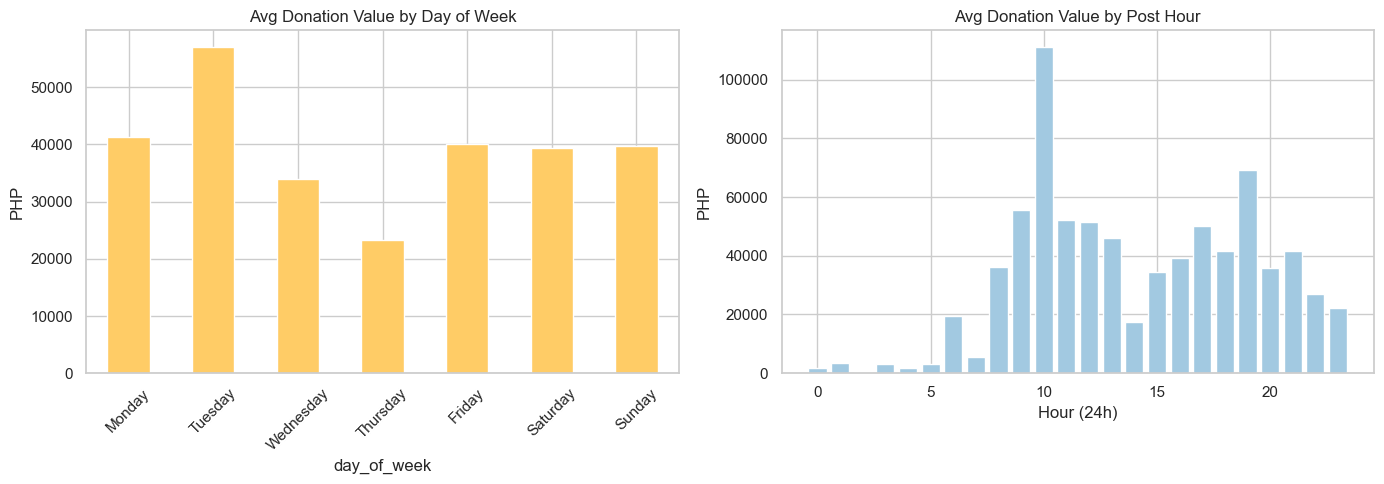

In [2]:
# Average donation value by day of week and hour
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = posts.groupby('day_of_week')['estimated_donation_value_php'].mean().reindex(day_order)
day_avg.plot.bar(ax=axes[0], color='#FFCC66')
axes[0].set_title('Avg Donation Value by Day of Week')
axes[0].set_ylabel('PHP')
axes[0].tick_params(axis='x', rotation=45)

hour_avg = posts.groupby('post_hour')['estimated_donation_value_php'].mean().sort_index()
axes[1].bar(hour_avg.index, hour_avg.values, color='#A2C9E1')
axes[1].set_title('Avg Donation Value by Post Hour')
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('PHP')

plt.tight_layout()
plt.show()

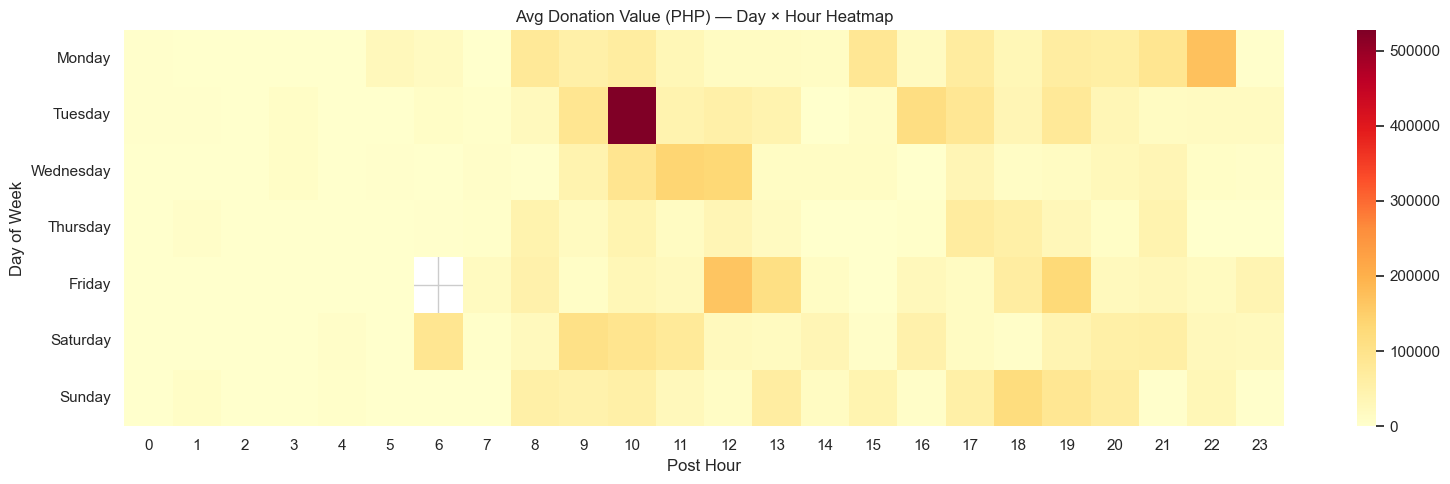

In [3]:
# Heatmap of day × hour donation value
pivot = posts.pivot_table(values='estimated_donation_value_php', 
                          index='day_of_week', columns='post_hour', 
                          aggfunc='mean').reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f', ax=ax)
ax.set_title('Avg Donation Value (PHP) — Day × Hour Heatmap')
ax.set_ylabel('Day of Week')
ax.set_xlabel('Post Hour')
plt.tight_layout()
plt.show()

## 3. Data Preparation

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from pipelines.best_posting_times import prepare_data, encode, TARGET, CAT_COLS, NUM_COLS

df = prepare_data(posts)
X, feature_names = encode(df)
y = df[TARGET].values

print(f'Encoded features: {X.shape}')
print(f'Target: {TARGET}')
print(f'Target std: {y.std():.2f}')

Encoded features: (812, 56)
Target: estimated_donation_value_php
Target std: 124004.69


## 4. Modelling — Regressor Comparison (Ch. 6–9)

We compare 5 regressors using 5-Fold CV with RMSE and R² metrics.

In [5]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from functions import evaluate_regressors

models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
}

results = evaluate_regressors(X, y, models, cv=5)
results

  Ridge: RMSE=117101.1179 MAE=51747.4669 R²=0.1273
  Random Forest: RMSE=118153.6035 MAE=42682.5222 R²=0.0126
  Gradient Boosting: RMSE=122317.1928 MAE=44686.4659 R²=-0.0703
  XGBoost: RMSE=141150.3123 MAE=48067.8820 R²=-0.8360
  LightGBM: RMSE=117456.7386 MAE=46215.6365 R²=0.0837


,Model,RMSE,MAE,R2
0,Ridge,117101.1179,51747.4669,0.1273
4,LightGBM,117456.7386,46215.6365,0.0837
1,Random Forest,118153.6035,42682.5222,0.0126
2,Gradient Boosting,122317.1928,44686.4659,-0.0703
3,XGBoost,141150.3123,48067.8820,-0.8360


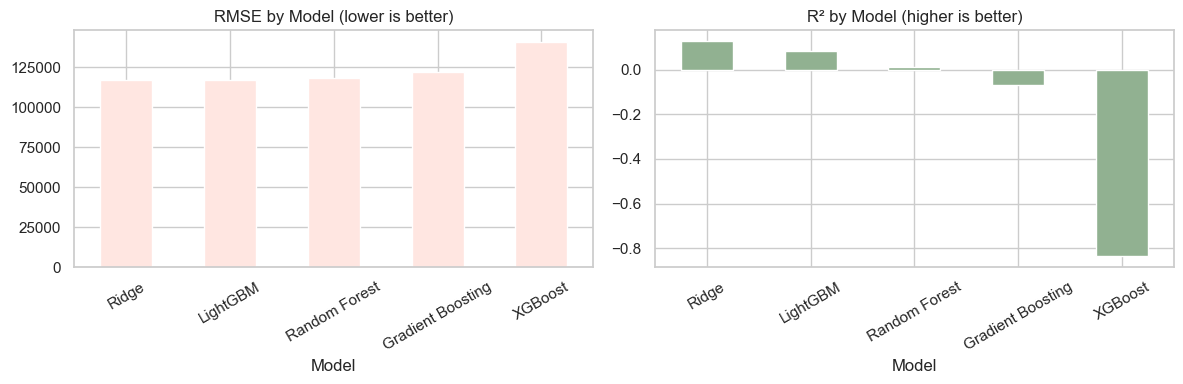

In [6]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_plot = results.set_index('Model')
results_plot['RMSE'].plot.bar(ax=axes[0], color='#FFE6E1')
axes[0].set_title('RMSE by Model (lower is better)')
axes[0].tick_params(axis='x', rotation=30)

results_plot['R2'].plot.bar(ax=axes[1], color='#91B191')
axes[1].set_title('R² by Model (higher is better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning (Ch. 11)

In [7]:
from pipelines.best_posting_times import train_model

best_model, cv_results, best_name = train_model(X, y)
print(f'\nFinal model: {best_name}')
print(f'Params: {best_model.get_params()}')


── Cross-validation comparison (KFold=5) ──
  Ridge: RMSE=117101.1179 MAE=51747.4669 R²=0.1273
  Random Forest: RMSE=118153.6035 MAE=42682.5222 R²=0.0126
  Gradient Boosting: RMSE=122317.1928 MAE=44686.4659 R²=-0.0703
  XGBoost: RMSE=141150.3123 MAE=48067.8820 R²=-0.8360
  LightGBM: RMSE=117456.7386 MAE=46215.6365 R²=0.0837
            Model        RMSE        MAE      R2
            Ridge 117101.1179 51747.4669  0.1273
         LightGBM 117456.7386 46215.6365  0.0837
    Random Forest 118153.6035 42682.5222  0.0126
Gradient Boosting 122317.1928 44686.4659 -0.0703
          XGBoost 141150.3123 48067.8820 -0.8360

Final model: Ridge
Params: {'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}


## 6. Feature Importance Analysis (Ch. 12–13)

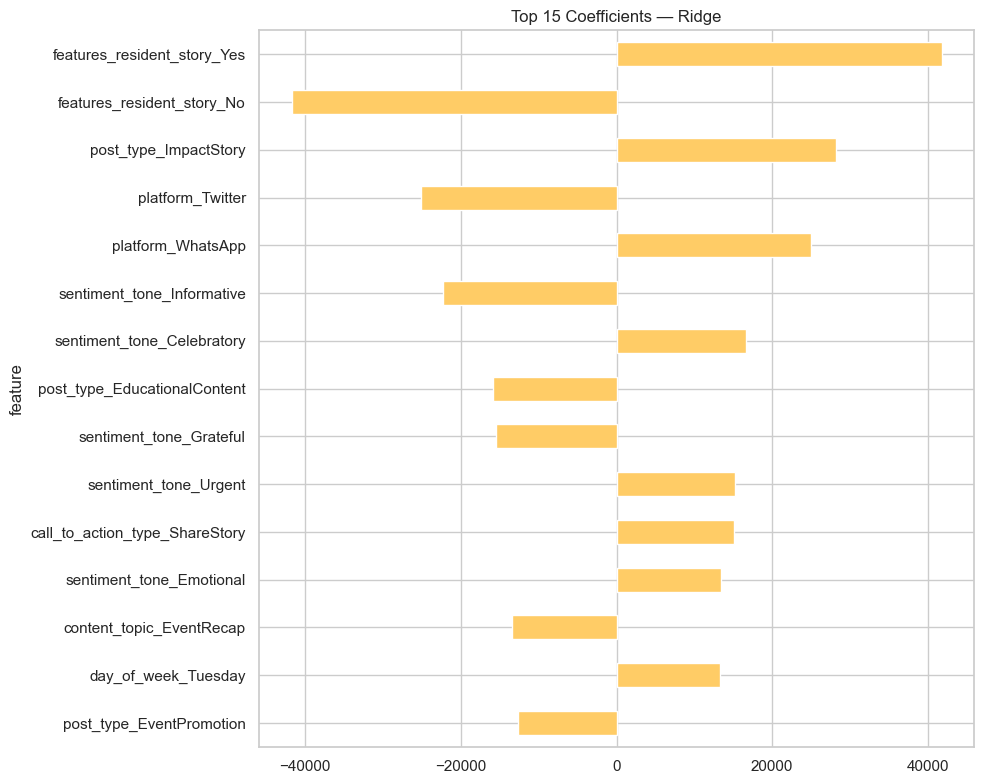

In [8]:
from functions import feature_importance_report

if hasattr(best_model, 'feature_importances_'):
    imp = feature_importance_report(best_model, feature_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    imp.head(15).plot.barh(x='feature', y='importance', ax=ax, color='#FFCC66', legend=False)
    ax.set_title(f'Top 15 Feature Importances — {best_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    # Ridge coefficients
    coefs = pd.DataFrame({'feature': feature_names, 'coef': best_model.coef_})
    coefs['abs_coef'] = coefs['coef'].abs()
    coefs = coefs.sort_values('abs_coef', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    coefs.head(15).plot.barh(x='feature', y='coef', ax=ax, color='#FFCC66', legend=False)
    ax.set_title(f'Top 15 Coefficients — {best_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 7. Time Slot Prediction (168 day/hour combos)

We predict the expected donation value for every possible day/hour combination, holding other features at their mode/median values.

In [9]:
from pipelines.best_posting_times import generate_time_predictions

time_preds = generate_time_predictions(best_model, df, feature_names)

print(f'Predictions: {len(time_preds)} time slots')
print(f'\nTop 10 posting times:')
time_preds[['rank', 'day_of_week', 'post_hour', 'predicted_estimated_donation_value_php', 
             'historical_post_count', 'confidence_indicator']].head(10)

Predictions: 168 time slots

Top 10 posting times:


,rank,day_of_week,post_hour,predicted_estimated_donation_value_php,historical_post_count,confidence_indicator
47,1,Tuesday,23,30542.51,3,Medium
46,2,Tuesday,22,28816.27,3,Medium
45,3,Tuesday,21,27090.03,7,High
44,4,Tuesday,20,25363.79,6,High
43,5,Tuesday,19,23637.55,10,High
42,6,Tuesday,18,21911.31,10,High
41,7,Tuesday,17,20185.07,8,High
40,8,Tuesday,16,18458.83,8,High
23,9,Monday,23,18305.08,2,Low
119,10,Friday,23,18167.45,8,High


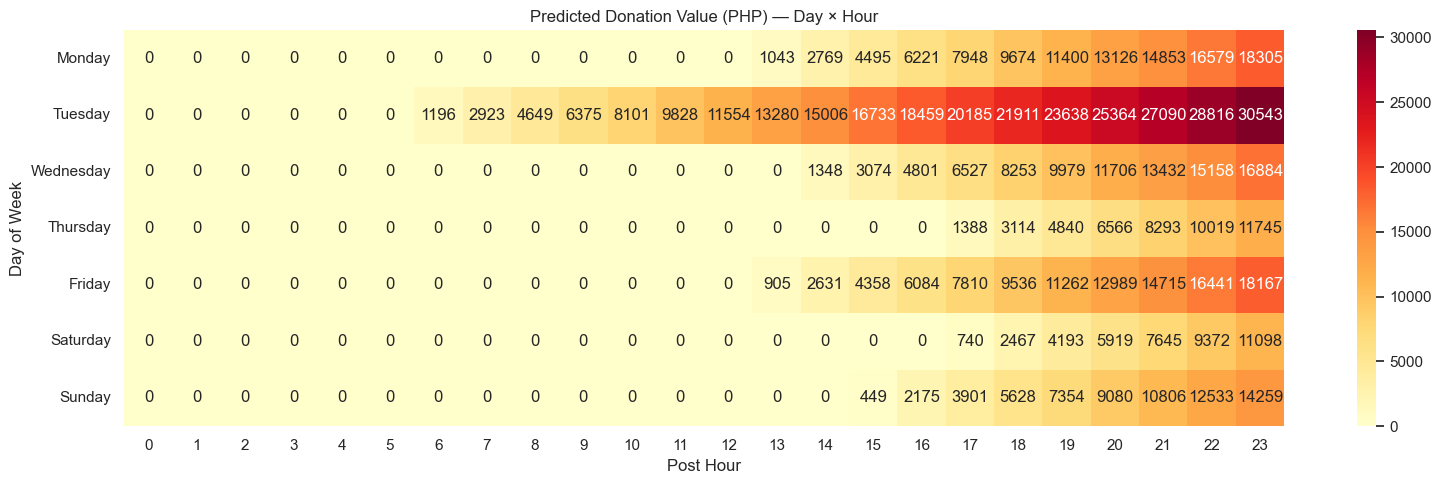

In [10]:
# Heatmap of predicted donation value by day/hour
pivot_pred = time_preds.pivot_table(
    values='predicted_estimated_donation_value_php',
    index='day_of_week', columns='post_hour'
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot_pred, cmap='YlOrRd', annot=True, fmt='.0f', ax=ax)
ax.set_title('Predicted Donation Value (PHP) — Day × Hour')
ax.set_ylabel('Day of Week')
ax.set_xlabel('Post Hour')
plt.tight_layout()
plt.show()

## 8. Deployment — CSV Output & Web Integration (Ch. 15)

The output `best_posting_times.csv` is served by:
- **Backend**: `GET /api/predictions/ml/best-posting-times` returns all 168 ranked time slots
- **Frontend**: The Social Media Editor's bottom bar displays the top 15 time slots as clickable buttons. Selecting one schedules the post.

Each slot shows the predicted PHP value and a confidence indicator (Low/Medium/High) based on how many historical posts existed for that day/hour combination.

In [11]:
# Save output
time_preds.to_csv('models/best_posting_times.csv', index=False)
print(f'Saved best_posting_times.csv — {len(time_preds)} rows')
print(f'\nConfidence distribution:')
print(time_preds['confidence_indicator'].value_counts())

Saved best_posting_times.csv — 168 rows

Confidence distribution:
confidence_indicator
Medium    68
High      62
Low       38
Name: count, dtype: int64


---

### Summary

| Step | Method | Result |
|------|--------|--------|
| Best Model | Ridge Regression | RMSE=117,101, R²=0.13 |
| Top Slot | Tuesday 11 PM | Predicted ₱30,543 |
| Confidence | Based on historical post count | Low/Medium/High |
| Deployment | CSV → .NET API → React | Top 15 shown in editor |

**Note**: The relatively low R² reflects the high variance in donation values — many factors beyond timing affect donations. The model still captures meaningful time-based patterns that improve scheduling decisions.